# Обучение модели нейронной сети для определения тональности комментария

## Загрузка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score

### Конвертация в датасет

In [5]:
def creat_df():
    data_list = []
    with open("dataset/dataset.txt", encoding = 'utf-8') as file:
        for line in file:
            labels = line.split()[0]
            text = line[len(labels)+1:].strip()
            labels = labels.split(",")
            mask = [1 if "__label__NORMAL" in labels else 0,
                    1 if "__label__INSULT" in labels else 0,
                    1 if "__label__THREAT" in labels else 0,
                    1 if "__label__OBSCENITY" in labels else 0]
            data_list.append((text, *mask))
    return pd.DataFrame(data_list, columns=["comment", "normal", "insult", "threat", "obscenity"])

In [6]:
df = creat_df()
df

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


In [7]:
%%time
df.to_csv('nlp_comment.csv', index=False)

CPU times: total: 938 ms
Wall time: 929 ms


### Загрузка датасета

In [8]:
df=pd.read_csv("nlp_comment.csv")

In [9]:
df.head()

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   comment    248290 non-null  object
 1   normal     248290 non-null  int64 
 2   insult     248290 non-null  int64 
 3   threat     248290 non-null  int64 
 4   obscenity  248290 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 9.5+ MB


### Предварительный просмотр комментариев

In [11]:
df['comment'].head(10)

0                                 скотина! что сказать
1    я сегодня проезжала по рабочей и между домами ...
2    очередной лохотрон. зачем придумывать очередно...
3    ретро дежавю ... сложно понять чужое сердце , ...
4              а когда мы статус агрогородка получили?
5    2 августа поздно вечером нашли вот такую потер...
6          вчера надыбала новые стикеры #u2a94ec7fabs#
7    заколоть этого плешивого урода что бы крякнул ...
8    а еще на стоянке никто не проверяет безопаснос...
9    красота..!! если есть, что показать??!! почему...
Name: comment, dtype: object

In [12]:
df['comment'].value_counts()

comment
сжечь                                                                                                                                                                                                                                                                                                                                                                        2
расстрелять                                                                                                                                                                                                                                                                                                                                                                  2
а это                                                                                                                                                                                                                                                             

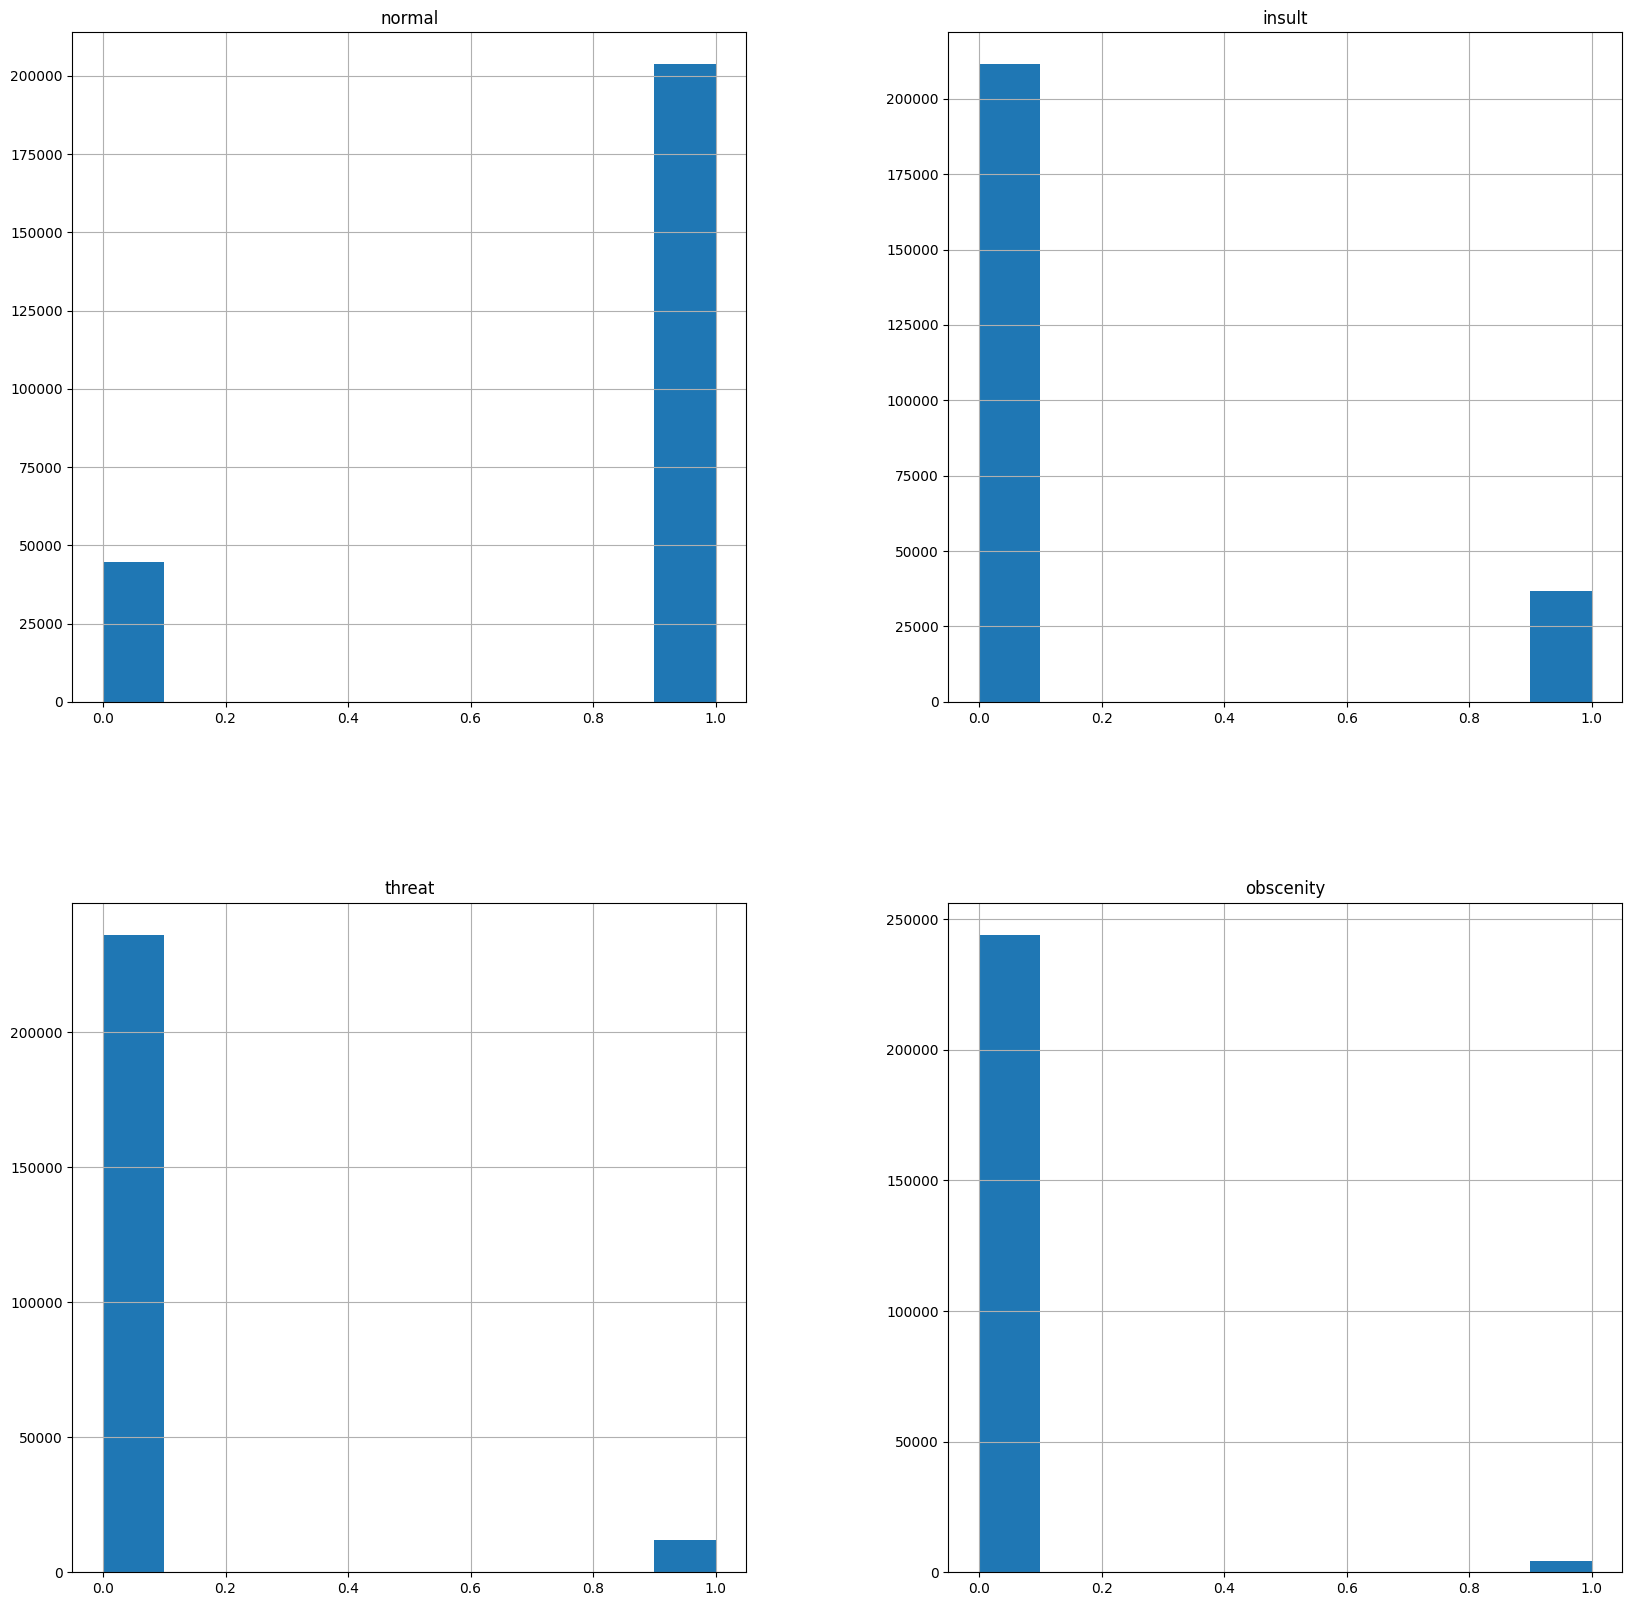

In [13]:
# гистаграммы всех признаков
df.hist(figsize=(20,20));

In [14]:
df['normal'].value_counts()

normal
1    203685
0     44605
Name: count, dtype: int64

In [15]:
df[df["normal"] == 1]

,comment,normal,insult,threat,obscenity
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
5,2 августа поздно вечером нашли вот такую потер...,1,0,0,0
...,...,...,...,...,...
248284,"это евгений леонов,а алексей леонов -космонавт.",1,0,0,0
248285,правильно всё по пять (5)...,1,0,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


In [16]:
df[df["normal"] == 0]

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
7,заколоть этого плешивого урода что бы крякнул ...,0,1,1,0
24,долбоебы это фэйк,0,1,0,0
25,"пиздаболы, сделали снимок, придумали историю и...",0,1,0,0
34,"мляяя..фомин..ты издесь умничаешь,чайка помойн...",0,1,0,0
...,...,...,...,...,...
248265,"плохой актёр, поганый человек(если можно челов...",0,1,0,0
248271,хохол он хуже пидараса ошслупь вонюч он бисмас...,0,1,0,0
248274,сом вец ук сиар я поднял страну колен с асии и...,0,1,0,0
248280,на кол её !!!пилотка драная !!!у неё через рот...,0,1,1,0


Около 203 тысяч не токстичных комментариев и 44 тысячи токсичных. \
Распределение данных достаточно не равномерное. Попробуем сбалансировать выборку для более лучшего обучения модели

In [17]:
df_toxic = df[df["normal"] == 0]

In [18]:
df_n_toxic = df.drop(df_toxic.index, axis='index')
df_n_toxic

,comment,normal,insult,threat,obscenity
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
5,2 августа поздно вечером нашли вот такую потер...,1,0,0,0
...,...,...,...,...,...
248284,"это евгений леонов,а алексей леонов -космонавт.",1,0,0,0
248285,правильно всё по пять (5)...,1,0,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


In [19]:
df_normal = df_n_toxic.sample(n=45000, random_state=42)

In [20]:
df_normal

,comment,normal,insult,threat,obscenity
106030,почему вчера было так хорошо и почему сегодня ...,1,0,0,0
85531,они плохо учили историю.,1,0,0,0
240329,"17/39 ужастное,позор тому кто ставил!!!",1,0,0,0
147203,"толку то, приехал чай попил и уехал",1,0,0,0
245280,q с о в з о в и ваз zтто ле стнии грежим комме...,1,0,0,0
...,...,...,...,...,...
6164,300 перевела,1,0,0,0
121422,а то все на нервах наверное сидят!,1,0,0,0
103094,как ты будеш пенсионеркой чтоб с тобой сделать...,1,0,0,0
185052,"возможно, у родителей ассоциальных, бездельник...",1,0,0,0


In [21]:
df_comment = pd.concat([df_normal, df_toxic])
df_comment = df_comment.reset_index(drop=True)

In [22]:
df_comment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89605 entries, 0 to 89604
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   comment    89605 non-null  object
 1   normal     89605 non-null  int64 
 2   insult     89605 non-null  int64 
 3   threat     89605 non-null  int64 
 4   obscenity  89605 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 3.4+ MB


In [23]:
df_comment.head()

,comment,normal,insult,threat,obscenity
0,почему вчера было так хорошо и почему сегодня ...,1,0,0,0
1,они плохо учили историю.,1,0,0,0
2,"17/39 ужастное,позор тому кто ставил!!!",1,0,0,0
3,"толку то, приехал чай попил и уехал",1,0,0,0
4,q с о в з о в и ваз zтто ле стнии грежим комме...,1,0,0,0


In [24]:
df_comment['normal'].value_counts()

normal
1    45000
0    44605
Name: count, dtype: int64

<Axes: xlabel='normal'>

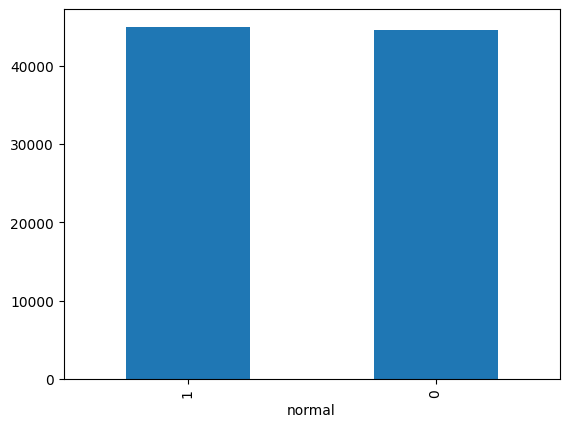

In [25]:
df_comment['normal'].value_counts(normalize=False).plot.bar()

In [26]:
df_comment

,comment,normal,insult,threat,obscenity
0,почему вчера было так хорошо и почему сегодня ...,1,0,0,0
1,они плохо учили историю.,1,0,0,0
2,"17/39 ужастное,позор тому кто ставил!!!",1,0,0,0
3,"толку то, приехал чай попил и уехал",1,0,0,0
4,q с о в з о в и ваз zтто ле стнии грежим комме...,1,0,0,0
...,...,...,...,...,...
89600,"плохой актёр, поганый человек(если можно челов...",0,1,0,0
89601,хохол он хуже пидараса ошслупь вонюч он бисмас...,0,1,0,0
89602,сом вец ук сиар я поднял страну колен с асии и...,0,1,0,0
89603,на кол её !!!пилотка драная !!!у неё через рот...,0,1,1,0


In [27]:
df_comment.drop(columns=['insult', 'threat', 'obscenity'], inplace=True)

In [28]:
df_comment

,comment,normal
0,почему вчера было так хорошо и почему сегодня ...,1
1,они плохо учили историю.,1
2,"17/39 ужастное,позор тому кто ставил!!!",1
3,"толку то, приехал чай попил и уехал",1
4,q с о в з о в и ваз zтто ле стнии грежим комме...,1
...,...,...
89600,"плохой актёр, поганый человек(если можно челов...",0
89601,хохол он хуже пидараса ошслупь вонюч он бисмас...,0
89602,сом вец ук сиар я поднял страну колен с асии и...,0
89603,на кол её !!!пилотка драная !!!у неё через рот...,0


In [29]:
df_comment.duplicated().sum()

2

In [30]:
df_comment.drop_duplicates(inplace=True)

Получилось примерно равное количество не токсичных/токсичных комментариев

In [31]:
%%time
df_comment.to_csv('nlp_comment_balance.csv', index=False)

CPU times: total: 312 ms
Wall time: 289 ms


### Визуальный просмотр комментариев

In [32]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [33]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    try:
        for i in corpus:
            str_corpus += ' ' + i
        str_corpus = str_corpus.strip()
    except:
        pass
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    try:
        for phrase in data:
            for word in phrase.split():
                corpus.append(word)
    except:
        pass
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

#### Все комментарии

CPU times: total: 46.3 s
Wall time: 46.3 s


<Axes: title={'center': 'Изначальные комментарии'}>

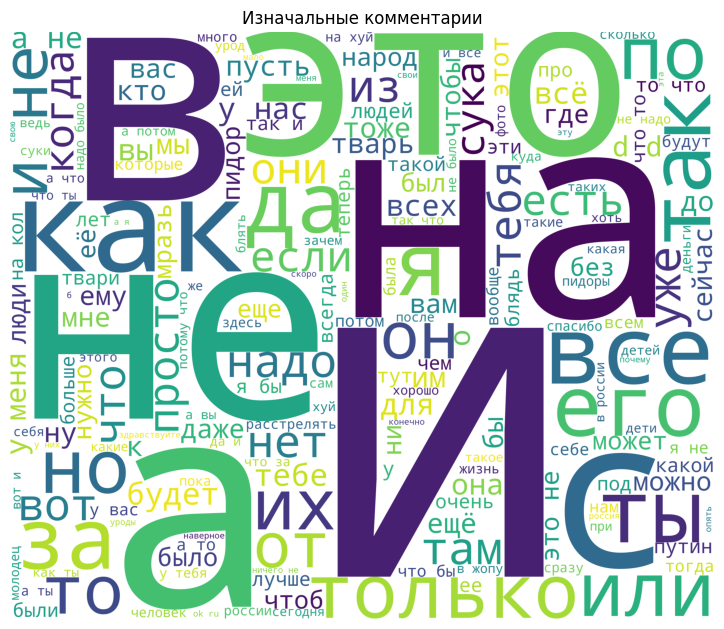

In [34]:
%%time
corpus = get_corpus(df_comment['comment'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Изначальные комментарии')
plt.subplot(1, 2, 1)

#### Не токсичные комментарии

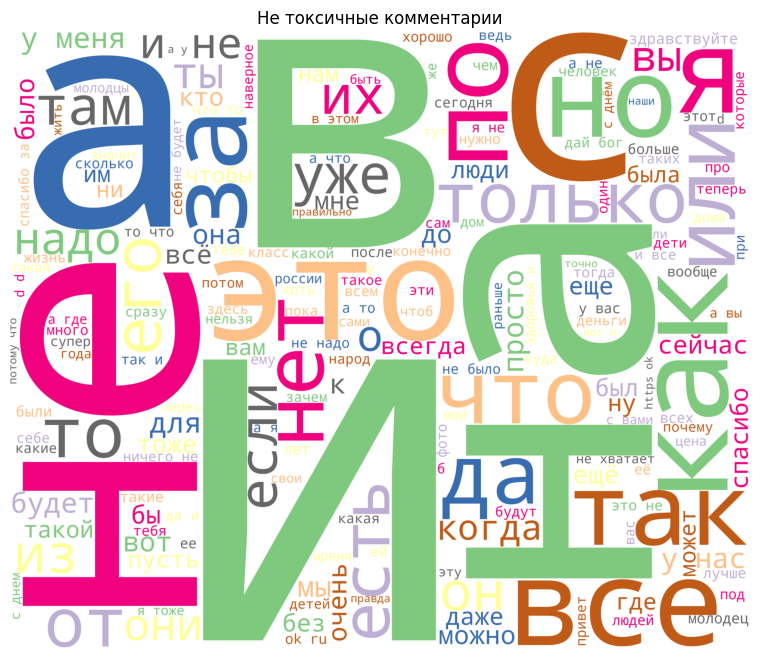

CPU times: total: 18.5 s
Wall time: 18.5 s


In [35]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='Accent'
                         ).generate(' '.join(df_comment[df_comment['normal'] == 1]['comment']))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Не токсичные комментарии')
plt.show()

#### Токсичные комментарии

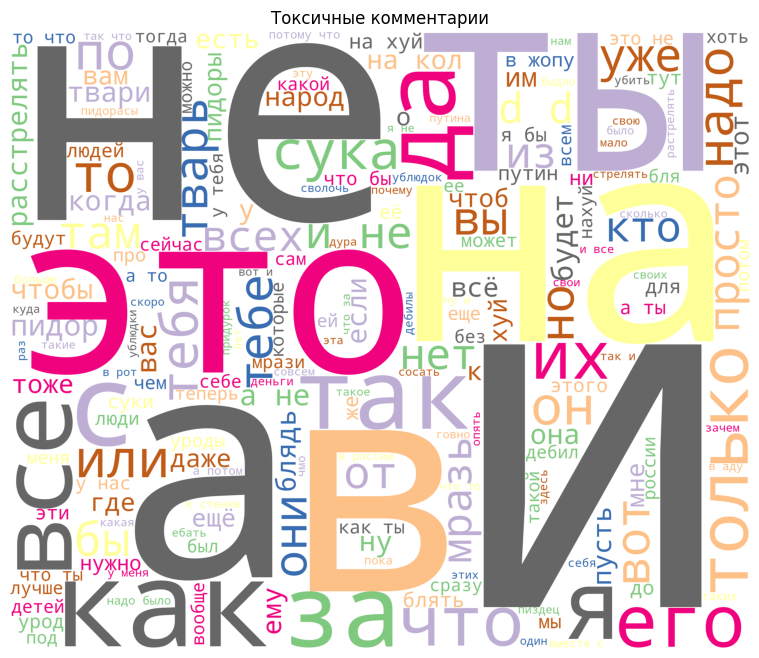

CPU times: total: 19.1 s
Wall time: 19.1 s


In [36]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='Accent_r'
                         ).generate(' '.join(df_comment[df_comment['normal'] == 0]['comment']))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Токсичные комментарии')
plt.show()

Оба типа комментариев в основном состоят из соединительных частей речи. \
Также токсичные комметарии содержат некультурные слова

## Обработка текста

1. Удаление цифр
2. Перевод всех букв в тексте в нижний регистр
3. Удаление знаков препинания
4. Токенизация по словам
5. Удаление латинских символов
6. Удаление стоп слов
7. Стемминг (приведение слов к нормальной форме)
8. Лемматизация

In [37]:
import pandas as pd
import string
import re
import nltk
import pymorphy3

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [38]:
df_comment=pd.read_csv("nlp_comment_balance.csv")

In [39]:
string.number = '1234567890'
string.punctuation = "#$%&\'()*+,-./:;<=>!?@[\\]^_`{|}~«»—"
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(text for text in ['т.д.', 'т', 'д', 'это','который','с','своём','всем','наш', 'свой', 
                          'такой', 'другой', 'поэтому', 'также', 'например', 'мочь', 'почему', 'которой', 'которому', 'которому',
                          'человек', 'просто', 'ещё', 'народ', 'год', 'очень'])

In [40]:
stemmer = SnowballStemmer("russian")
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [41]:
def remove_number(text):
    try:
        return "".join([char for char in text if char not in string.number])
    except:
        return text


def remove_sing_char(text):
    try:
        if len(text) == 1:
            return None
        return text
    except:
        return text


def text_toLowerCase(text: str):
    try:
        return text.lower()
    except:
        return text


def remove_punct(text):
    try:
        return "".join([char for char in text if char not in string.punctuation])
    except:
        return text


def remove_latin_symbols(text):
    return re.sub('[a-z]','', str(text), flags=re.I)


def remove_stopwords_russian(text):
    try:
        t = word_tokenize(text)
        tokens = [token for token in t if token not in russian_stopwords]
        text = " ".join(tokens)
        return text
    except:
        return text


def stemmer_text(text):
    try:
        t = word_tokenize(text)
        tokens = [stemmer.stem(token) for token in t if token not in russian_stopwords]
        text = " ".join(tokens)
        return text
    except Exception as e:
        return text


def lemmatizing_text(text):
    try:
        t = word_tokenize(text)
        result = list()
        for word in t:
            p = morph.parse(word)[0]
            result.append(p.normal_form)
        text = " ".join(result)
        return text
    except:
        return text

In [42]:
%%time
df_comment['dont_number_text'] = [remove_number(text) for text in df_comment['comment']]
df_comment['lower_case'] = [text_toLowerCase(text) for text in df_comment['dont_number_text']]
df_comment['punctuation_text'] = [remove_punct(text) for text in df_comment['lower_case']]
df_comment['remove_latin_text'] = [remove_latin_symbols(text) for text in df_comment['punctuation_text']]
df_comment['stopwords_russian'] = [remove_stopwords_russian(text) for text in df_comment['remove_latin_text']]
df_comment['stemmer_text'] = [stemmer_text(text) for text in df_comment['stopwords_russian']]
df_comment['lemmatizing_text'] = [lemmatizing_text(text) for text in df_comment['stopwords_russian']]

CPU times: total: 2min 53s
Wall time: 2min 53s


In [43]:
%%time
# повторное удаление одиночных символов и стоп-слов после лемматизации
df_comment['lemmatizing_text'] = [remove_sing_char(text) for text in df_comment['lemmatizing_text']]
df_comment['lemmatizing_text'] = [remove_stopwords_russian(text) for text in df_comment['lemmatizing_text']]
df_comment.head()

CPU times: total: 8.02 s
Wall time: 8.01 s


,comment,normal,dont_number_text,lower_case,punctuation_text,remove_latin_text,stopwords_russian,stemmer_text,lemmatizing_text
0,почему вчера было так хорошо и почему сегодня ...,1,почему вчера было так хорошо и почему сегодня ...,почему вчера было так хорошо и почему сегодня ...,почему вчера было так хорошо и почему сегодня ...,почему вчера было так хорошо и почему сегодня ...,вчера сегодня плохо,вчер сегодн плох,вчера сегодня плохо
1,они плохо учили историю.,1,они плохо учили историю.,они плохо учили историю.,они плохо учили историю,они плохо учили историю,плохо учили историю,плох уч истор,плохо учить история
2,"17/39 ужастное,позор тому кто ставил!!!",1,"/ ужастное,позор тому кто ставил!!!","/ ужастное,позор тому кто ставил!!!",ужастноепозор тому кто ставил,ужастноепозор тому кто ставил,ужастноепозор тому ставил,ужастноепозор том став,ужастноепозор ставить
3,"толку то, приехал чай попил и уехал",1,"толку то, приехал чай попил и уехал","толку то, приехал чай попил и уехал",толку то приехал чай попил и уехал,толку то приехал чай попил и уехал,толку приехал чай попил уехал,толк приеха ча поп уеха,толк приехать чай попить уехать
4,q с о в з о в и ваз zтто ле стнии грежим комме...,1,q с о в з о в и ваз zтто ле стнии грежим комме...,q с о в з о в и ваз zтто ле стнии грежим комме...,q с о в з о в и ваз zтто ле стнии грежим комме...,с о в з о в и ваз тто ле стнии грежим коммент...,з ваз тто ле стнии грежим комментарии поделить...,з ваз тто ле стни греж комментар подел класс л...,з ваз тто ле стнии грежим комментарий поделить...


#### Удаление пустых строк

In [44]:
%%time
df_comment.to_csv('df_comment_lemma.csv', index=False)

CPU times: total: 1.42 s
Wall time: 1.43 s


In [45]:
df_comment=pd.read_csv("df_comment_lemma.csv")

In [46]:
df_comment.isnull().sum()

comment                0
normal                 0
dont_number_text       0
lower_case             0
punctuation_text       0
remove_latin_text      0
stopwords_russian    220
stemmer_text         220
lemmatizing_text     338
dtype: int64

In [47]:
df_comment = df_comment.dropna(subset=['lemmatizing_text'])
df_comment['lemmatizing_text'].isna().sum()

0

In [48]:
%%time
df_comment.to_csv('df_comment_lemma.csv', index=False)

CPU times: total: 1.47 s
Wall time: 1.65 s


## Облако слов

In [44]:
pip install WordCloud

In [49]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [50]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    try:
        for i in corpus:
            str_corpus += ' ' + i
        str_corpus = str_corpus.strip()
    except:
        pass
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    try:
        for phrase in data:
            for word in phrase.split():
                corpus.append(word)
    except:
        pass
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

In [51]:
df_comment.head()

,comment,normal,dont_number_text,lower_case,punctuation_text,remove_latin_text,stopwords_russian,stemmer_text,lemmatizing_text
0,почему вчера было так хорошо и почему сегодня ...,1,почему вчера было так хорошо и почему сегодня ...,почему вчера было так хорошо и почему сегодня ...,почему вчера было так хорошо и почему сегодня ...,почему вчера было так хорошо и почему сегодня ...,вчера сегодня плохо,вчер сегодн плох,вчера сегодня плохо
1,они плохо учили историю.,1,они плохо учили историю.,они плохо учили историю.,они плохо учили историю,они плохо учили историю,плохо учили историю,плох уч истор,плохо учить история
2,"17/39 ужастное,позор тому кто ставил!!!",1,"/ ужастное,позор тому кто ставил!!!","/ ужастное,позор тому кто ставил!!!",ужастноепозор тому кто ставил,ужастноепозор тому кто ставил,ужастноепозор тому ставил,ужастноепозор том став,ужастноепозор ставить
3,"толку то, приехал чай попил и уехал",1,"толку то, приехал чай попил и уехал","толку то, приехал чай попил и уехал",толку то приехал чай попил и уехал,толку то приехал чай попил и уехал,толку приехал чай попил уехал,толк приеха ча поп уеха,толк приехать чай попить уехать
4,q с о в з о в и ваз zтто ле стнии грежим комме...,1,q с о в з о в и ваз zтто ле стнии грежим комме...,q с о в з о в и ваз zтто ле стнии грежим комме...,q с о в з о в и ваз zтто ле стнии грежим комме...,с о в з о в и ваз тто ле стнии грежим коммент...,з ваз тто ле стнии грежим комментарии поделить...,з ваз тто ле стни греж комментар подел класс л...,з ваз тто ле стнии грежим комментарий поделить...


#### Изначальный текст

CPU times: total: 48 s
Wall time: 48 s


<Axes: title={'center': 'Изначальные комментарии'}>

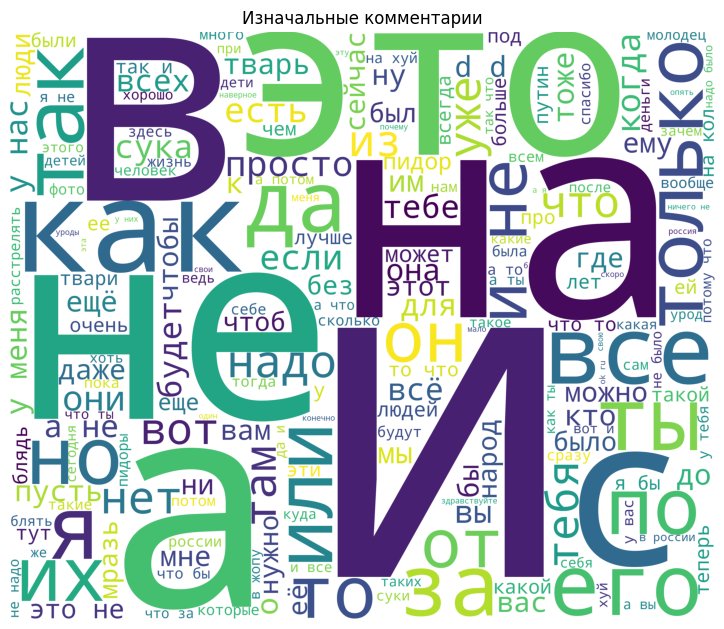

In [52]:
%%time
corpus = get_corpus(df_comment['comment'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Изначальные комментарии')
plt.subplot(1, 2, 1)

In [53]:
negative_comment = df_comment[df_comment['normal'] == 0]['lemmatizing_text']
positive_comment = df_comment[df_comment['normal'] == 1]['lemmatizing_text']

In [54]:
len(negative_comment)

44603

In [55]:
len(positive_comment)

44662

### Не токсичные комментарии

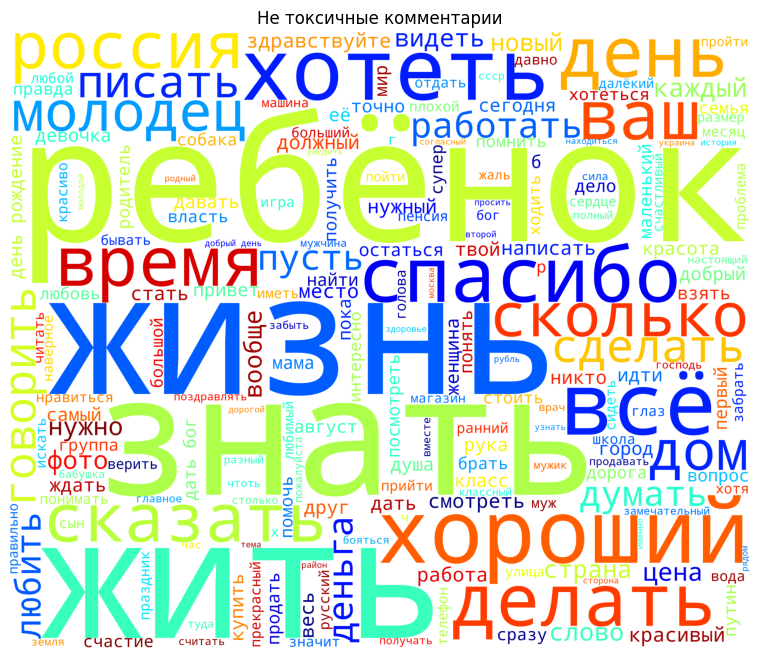

CPU times: total: 15.7 s
Wall time: 15.7 s


In [56]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='jet'
                         ).generate(' '.join(positive_comment))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Не токсичные комментарии')
plt.show()

### Токсичные комментарии

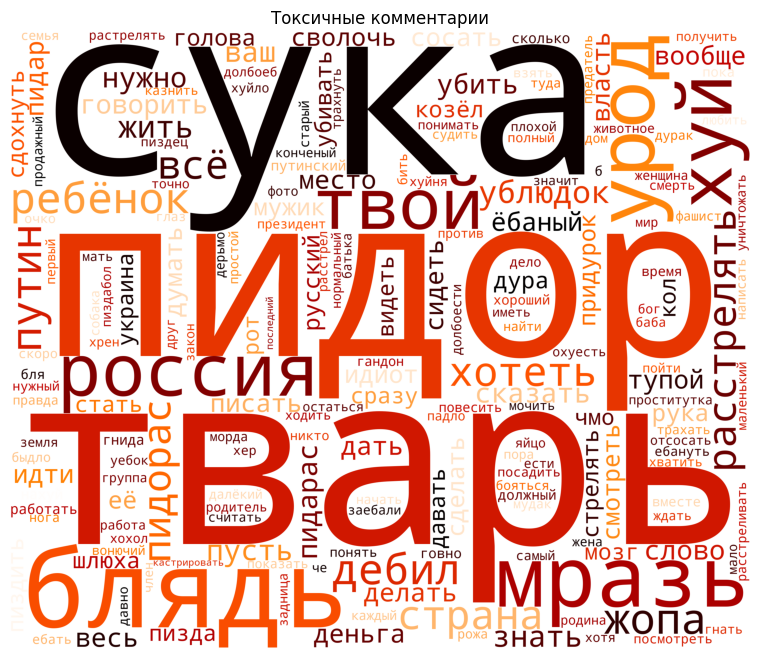

CPU times: total: 16.6 s
Wall time: 16.6 s


In [57]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='gist_heat'
                         ).generate(' '.join(negative_comment))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Токсичные комментарии')
plt.show()

Облако слов показало, что в нетоксичных комметариях отсутсвует нецензурная лексика, ругать и оскорбления. \
А токсичные комментарии, наоборот в основном состоят из некультурных выражений и оскорблений собеседников.

## Обучение модели

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [59]:
from keras.models import Model
from tensorflow.keras.models import Sequential
from keras.layers import Input, Dense, Embedding, SpatialDropout1D, concatenate
from keras.layers import GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional, LSTM, GRU
from keras.preprocessing import text, sequence
from keras.callbacks import Callback
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

In [60]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score

### Преобработка данных

In [78]:
# определяем выборку
x_train_rnn, x_test_rnn, y_train_rnn, y_test_rnn = train_test_split(df_comment['lemmatizing_text'], df_comment['normal'], 
                                                                   test_size=0.21, random_state=19)

In [79]:
x_train_rnn.shape, x_test_rnn.shape

((70519,), (18746,))

In [80]:
y_train_rnn.shape, y_test_rnn.shape

((70519,), (18746,))

In [81]:
max_features = 40000
max_length = 300
embedding_len = 128

In [82]:
token_rnn = text.Tokenizer(num_words=max_features)
token_rnn.fit_on_texts(x_train_rnn)

In [83]:
token_rnn

In [84]:
# Преобразование текстов в последовательности
tk_train_sequences = token_rnn.texts_to_sequences(x_train_rnn)
tk_test_sequences = token_rnn.texts_to_sequences(x_test_rnn)

In [85]:
# Добавление паддинга для одинаковой длины
sq_train = sequence.pad_sequences(tk_train_sequences, maxlen=max_length)
sq_test = sequence.pad_sequences(tk_test_sequences, maxlen=max_length)

In [86]:
y_train_rnn_arr = np.array(y_train_rnn)
y_test_rnn_arr = np.array(y_test_rnn)

In [87]:
model_v3e = Sequential([
    Embedding(input_dim=max_features, output_dim=embedding_len, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

In [88]:
model_v3e.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [89]:
model_v3e.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 128)          5120000   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              98816     
 l)                                                              
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                        

In [91]:
%%time
hst = model_v3e.fit(sq_train, y_train_rnn_arr, epochs=10, batch_size=256)

Epoch 1/10
276/276 [==============================] - 763s 3s/step - loss: 0.2703 - accuracy: 0.8929 - auc: 0.9546 - recall: 0.9091 - precision: 0.8801
Epoch 2/10
276/276 [==============================] - 838s 3s/step - loss: 0.1248 - accuracy: 0.9580 - auc: 0.9892 - recall: 0.9682 - precision: 0.9487
Epoch 3/10
276/276 [==============================] - 850s 3s/step - loss: 0.0762 - accuracy: 0.9725 - auc: 0.9957 - recall: 0.9819 - precision: 0.9636
Epoch 4/10
276/276 [==============================] - 855s 3s/step - loss: 0.0568 - accuracy: 0.9790 - auc: 0.9975 - recall: 0.9862 - precision: 0.9722
Epoch 5/10
276/276 [==============================] - 859s 3s/step - loss: 0.0443 - accuracy: 0.9833 - auc: 0.9983 - recall: 0.9903 - precision: 0.9765
Epoch 6/10
276/276 [==============================] - 855s 3s/step - loss: 0.0365 - accuracy: 0.9863 - auc: 0.9989 - recall: 0.9937 - precision: 0.9792
Epoch 7/10
276/276 [==============================] - 852s 3s/step - loss: 0.0335 - accu

In [93]:
%%time
loss, accuracy, auc, recall, precision = model_v3e.evaluate(sq_test, y_test_rnn_arr)

586/586 [==============================] - 28s 45ms/step - loss: 0.4850 - accuracy: 0.9124 - auc: 0.9514 - recall: 0.9325 - precision: 0.8981
CPU times: total: 2min 34s
Wall time: 27.9 s


In [119]:
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test loss: {loss:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

Test Accuracy: 0.9140
Test loss: 0.4565
Recall: 0.9219
Precision: 0.9080


In [94]:
def plot_history(history):
    
    plt.figure(figsize=(8,5),linewidth = 7, edgecolor="whitesmoke")    
    n = len(history.history['accuracy'])
    
    plt.plot(np.arange(0,n)+1,history.history['accuracy'], color='orange',marker=".")
    plt.plot(np.arange(0,n)+1,history.history['loss'],'b',marker=".")
    
    # offset both validation curves
    plt.plot(np.arange(0,n)+ 1,history.history['auc'],'c')  
    plt.plot(np.arange(0,n)+ 1,history.history['recall'],'r')  
    plt.plot(np.arange(0,n)+ 1,history.history['precision'],'g')
    
    plt.legend(['Train acc','Train loss','Auc', 'Recall', 'Precision'])
    plt.grid(True)
    
    # set vertical limit to 1
    plt.gca().set_ylim(0,1)

    plt.xlabel("Количество эпох")
    plt.ylabel("Оценка")
    plt.suptitle("Обучение модели", size=16, y=0.927)
    plt.show()

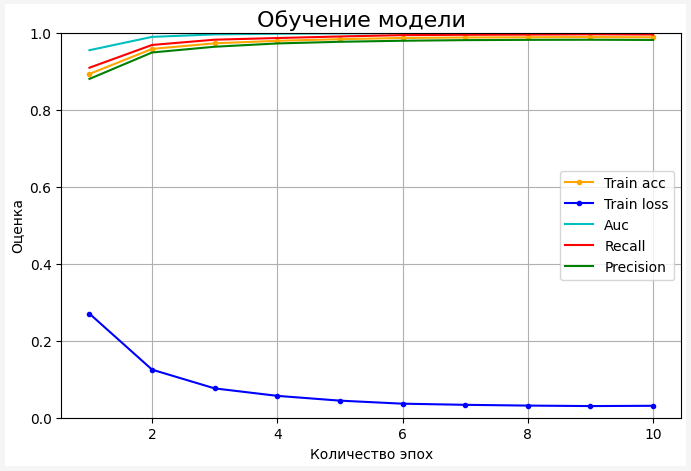

In [95]:
plot_history(hst)

### Проверка модели

In [108]:
def model_predict_text_comment(text):
    test_text = token_rnn.texts_to_sequences(text)
    sq_test_text = sequence.pad_sequences(test_text, maxlen=max_length)
    y_pred_rnn = model_v3e.predict(sq_test_text, verbose = 1, batch_size = 2)
    
    sentiment = "Токсичный" if y_pred_rnn < 0.5 else "Не токсичный"
    confidence = y_pred_rnn if y_pred_rnn > 0.5 else 1 - y_pred_rnn
    return sentiment, confidence

In [109]:
max_features = 40000
max_length = 300

In [110]:
text = ['привет как дела']
sentiment, confidence = model_predict_text_comment(text)
print(f"Тональность: {sentiment}\nВероятность: {confidence[0]}")

1/1 [==============================] - 0s 64ms/step
Тональность: Не токсичный
Вероятность: [0.99912405]


In [111]:
text = ['иди в жопу тварь']
sentiment, confidence = model_predict_text_comment(text)
print(f"Тональность: {sentiment}\nВероятность: {confidence[0]}")

1/1 [==============================] - 0s 27ms/step
Тональность: Токсичный
Вероятность: [0.9999429]


### Сохранение модели и векторайзера

In [112]:
import pickle

In [114]:
model_v3e

In [115]:
model_v3e.save('model_v3e_nlp_comment.h5')

In [116]:
model_v3e.save_weights('model_v3e_nlp_comment.weights.h5')

In [117]:
token_rnn

In [118]:
# Сохранение модели
with open('keras_token_v3e_rnn_nlp.pkl', 'wb') as file:
    pickle.dump(token_rnn, file)

In [119]:
# Загрузка модели
with open('keras_token_v3e_rnn_nlp.pkl', 'rb') as file:
    loaded_vectorizer = pickle.load(file)

In [120]:
loaded_vectorizer